###**DIP Practical-13**

**Name:** Yesha Pandya

**Enrollment Number:** 23BT04175

**Div:** 1 **Batch:** C

#### **Objective:**

Use any clustering algorithm for separating tumour from any given MRI image.


Magnetic Resonance Imaging (MRI) produces images where different tissues (and tumors) exhibit varying pixel intensities. Image segmentation partitions this image into multiple regions based on these characteristics.

K-Means clustering groups pixels into $k$ distinct clusters based on their intensity values. The algorithm minimizes the variance within each cluster by optimizing the following objective function:
$$J = \sum_{j=1}^{k} \sum_{i=1}^{n} ||x_i^{(j)} - c_j||^2$$

Where:
* $k$ is the number of clusters (e.g., background, white matter, gray matter, tumor)
* $n$ is the number of pixels
* $x_i^{(j)}$ is the pixel intensity
* $c_j$ is the centroid of the $j$-th cluster

Original MRI Scan:


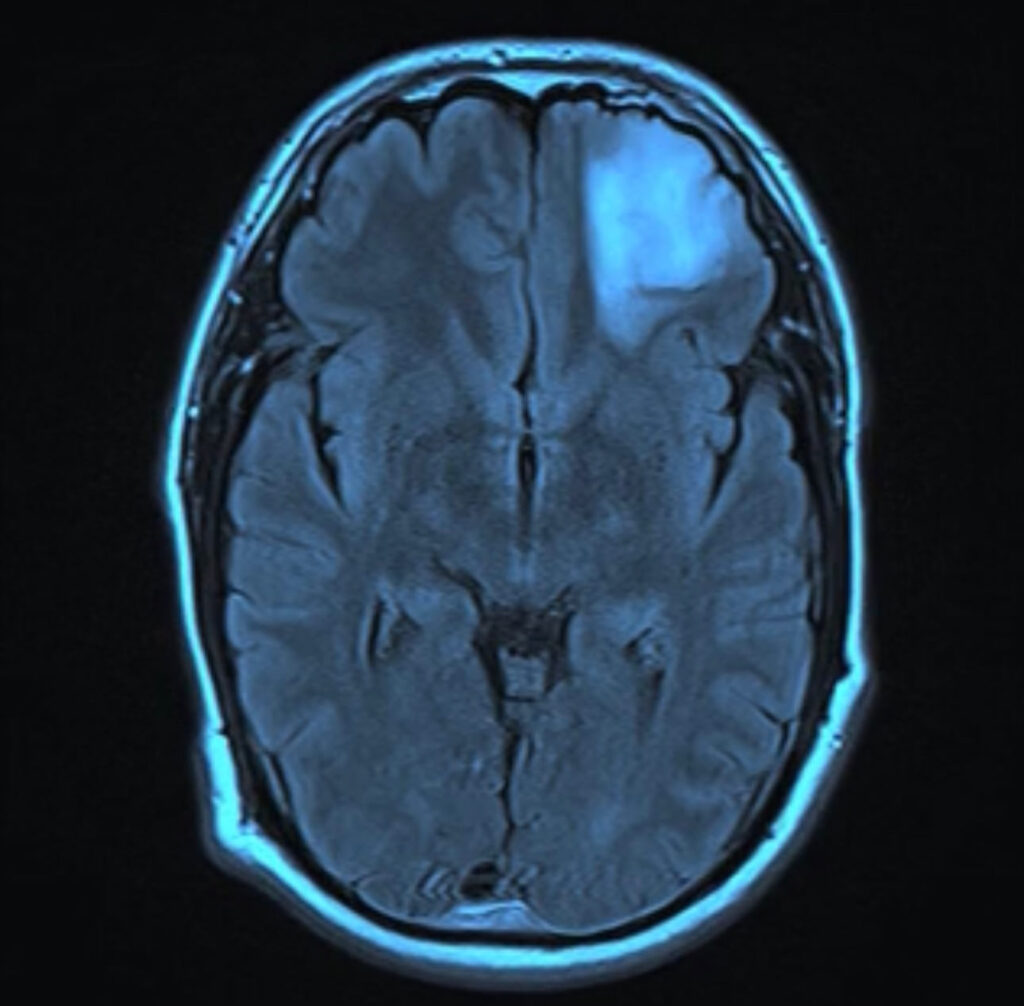

In [ ]:
# import necessary libraries
import cv2
import numpy as np
import urllib.request
from google.colab.patches import cv2_imshow # Required for displaying images in Colab

# load the image using OpenCV
original_img = cv2.imread("brain tumor.jpeg")

print("Original MRI Scan:")
cv2_imshow(original_img)

#### **Preprocessing**
Before applying the clustering algorithm, we need to preprocess the image:
- Convert to grayscale since intensity (brightness) is the primary feature we are clustering.
- Apply a Gaussian Blur to reduce noise and smooth the image, which prevents the algorithm from clustering random noisy pixels.

Preprocessed (Grayscale & Blurred) Image:


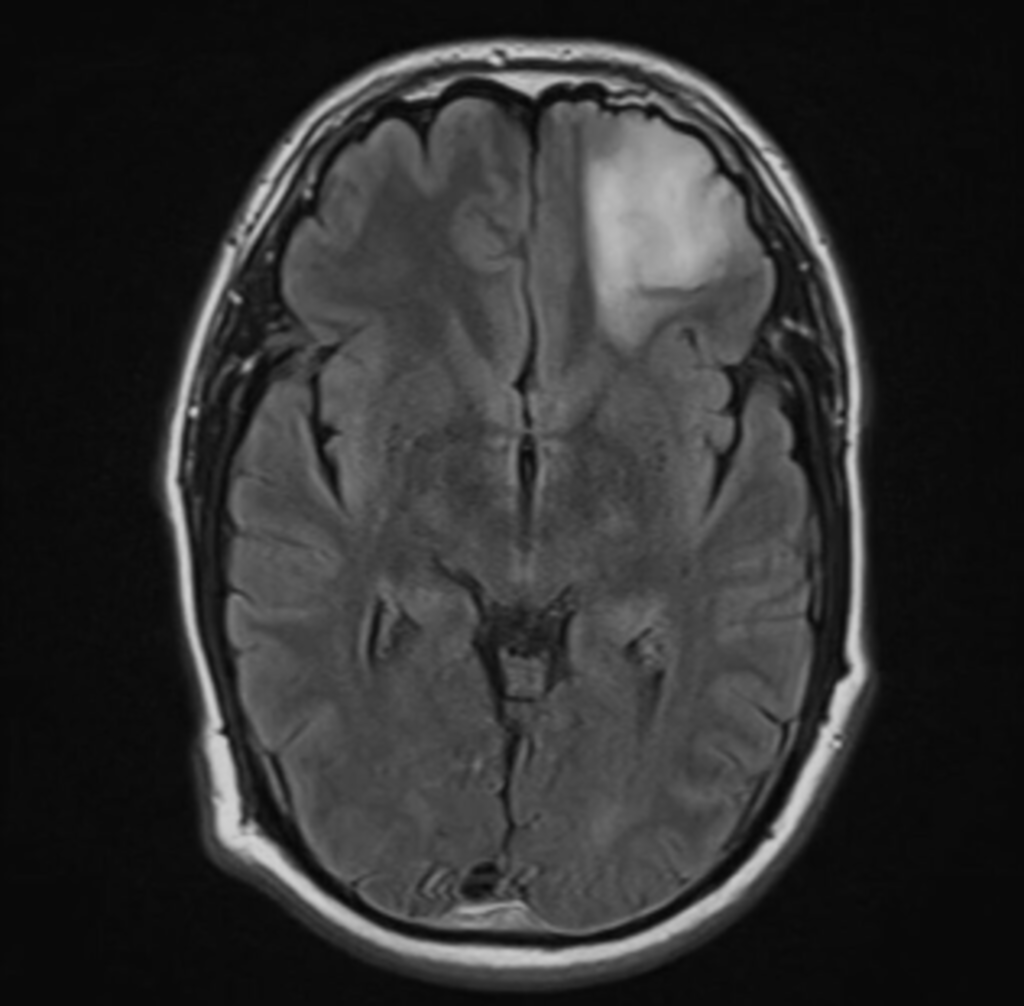

In [ ]:
# convert to grayscale
gray_img = cv2.cvtColor(original_img, cv2.COLOR_BGR2GRAY)

# apply Gaussian Blur to remove high-frequency noise
blurred_img = cv2.GaussianBlur(gray_img, (5, 5), 0)

# reshape the image into a 2D array of pixels and 1 color value (grayscale)
# K-Means requires a 2D array of data points
pixel_values = blurred_img.reshape((-1, 1))

# convert to float32, which is required by OpenCV's K-Means function
pixel_values = np.float32(pixel_values)

print("Preprocessed (Grayscale & Blurred) Image:")
cv2_imshow(blurred_img)

#### **Applying K-Means Clustering**
We'll partition the image pixels into `K` distinct clusters based on their intensity.

$K = 4$ is chosen to represent the distinct regions generally found in an MRI: Background, Healthy Brain Tissue (Gray/White matter), Skull/Bone and the Tumor.

Segmented Image showing 4 clusters:


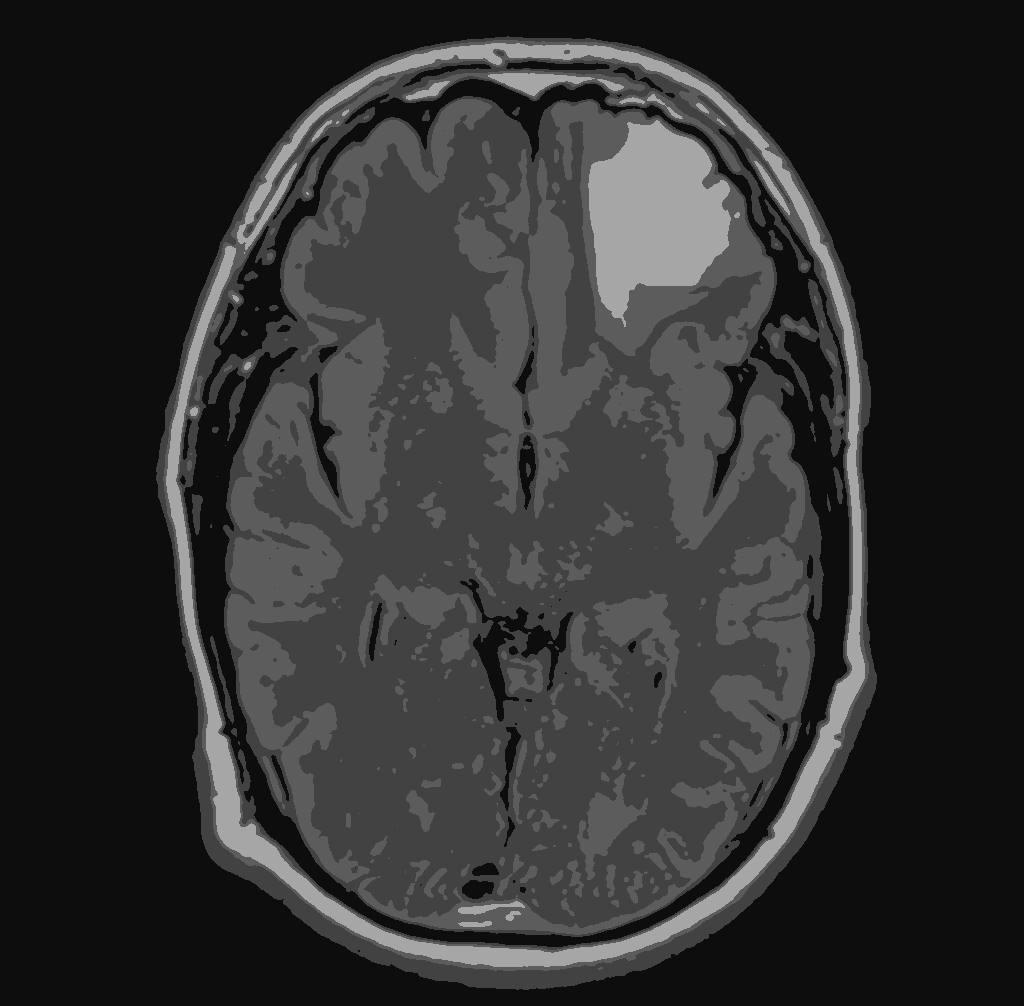

In [ ]:
# define stopping criteria for the algorithm:
# stop when either max iterations (100) are reached or the cluster centers move by less than epsilon (0.2)
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.2)

# set number of clusters
k = 4

# apply K-Means clustering
# returns: compactness, labels (cluster index for each pixel), and centers (intensity value of each cluster)
_, labels, (centers) = cv2.kmeans(pixel_values, k, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)

# convert the cluster centers back to 8-bit integers (0-255 range for image display)
centers = np.uint8(centers)

# map the labels back to the cluster centers to generate the segmented image
segmented_data = centers[labels.flatten()]

# reshape the 1D array back to the original 2D image dimensions
segmented_image = segmented_data.reshape((blurred_img.shape))

print(f"Segmented Image showing {k} clusters:")
cv2_imshow(segmented_image)

#### **Tumor Extraction**
In standard T2 or FLAIR MRI scans, tumors often appear as hyperintense (bright white) masses. We can isolate the tumor using steps:
- find the cluster center with the highest intensity value
- create a binary mask for that specific cluster
- apply morphological operations to clean up any scattered pixels.

Final Binary Mask of the Tumor:


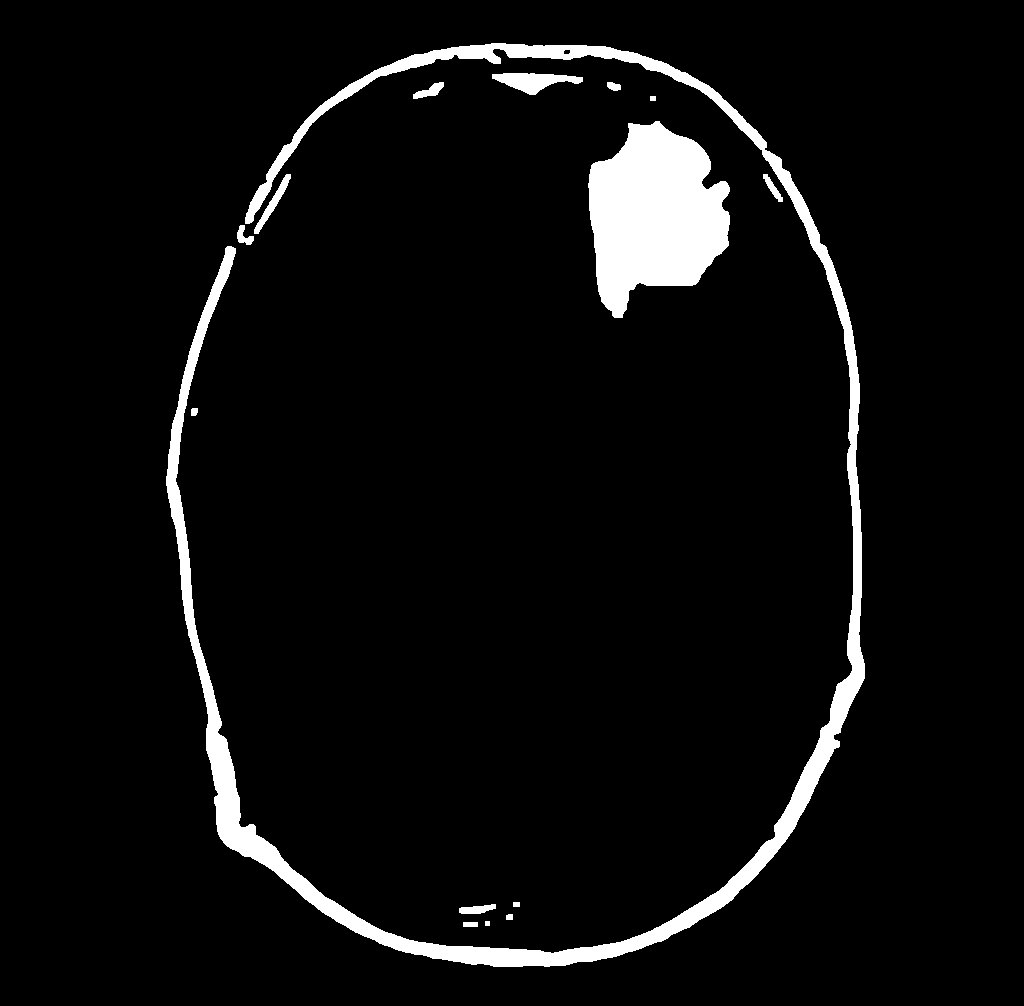

Extracted Tumor superimposed on Original Image:


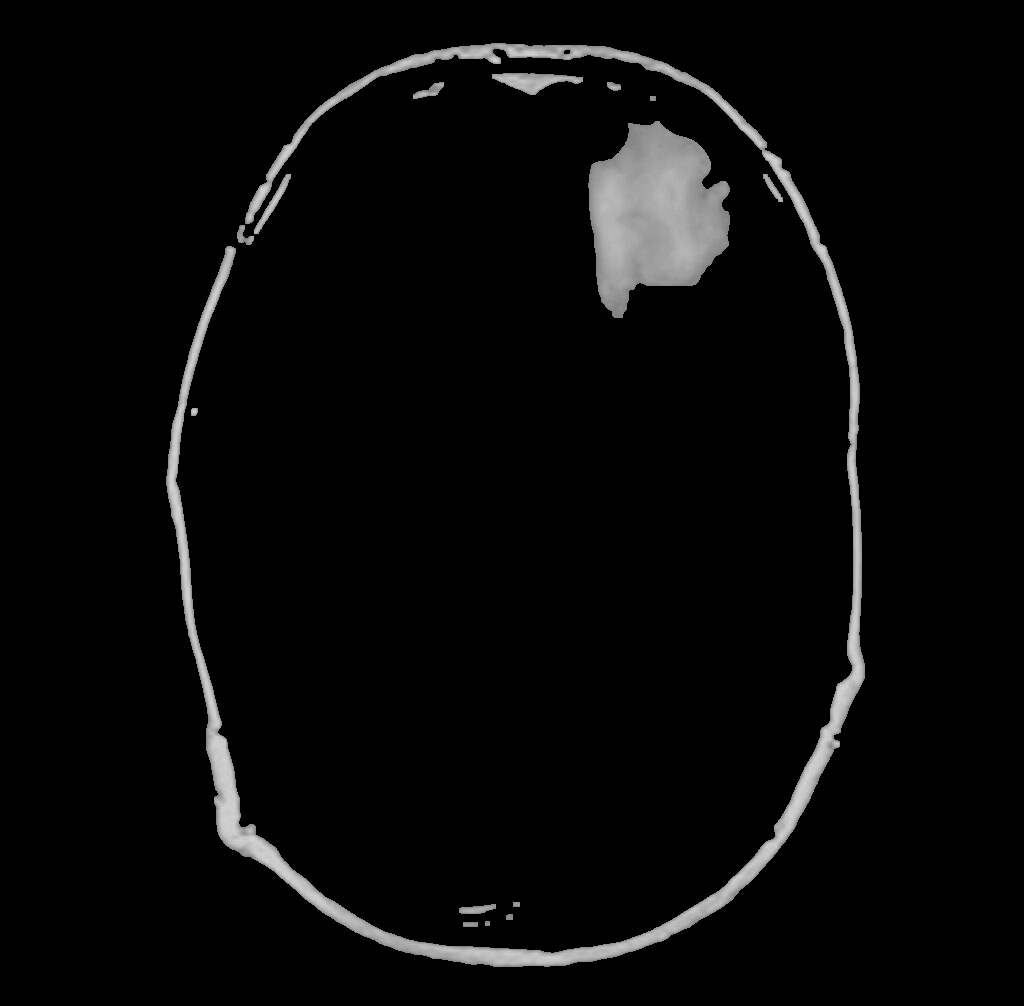

In [ ]:
# find the index of the cluster with the highest intensity (brightest region = tumor)
tumor_cluster_index = np.argmax(centers)

# create a binary mask: Set pixels of the tumor cluster to 255 (white) and everything else to 0 (black)
tumor_mask = np.uint8(labels.flatten() == tumor_cluster_index) * 255
tumor_mask = tumor_mask.reshape((blurred_img.shape))

# morphological opening: erosion followed by dilation to remove small noise points (false positives)
kernel = np.ones((5,5), np.uint8)
cleaned_tumor_mask = cv2.morphologyEx(tumor_mask, cv2.MORPH_OPEN, kernel)

# apply the mask to the original grayscale image to extract the actual tumor texture
isolated_tumor = cv2.bitwise_and(gray_img, gray_img, mask=cleaned_tumor_mask)

print("Final Binary Mask of the Tumor:")
cv2_imshow(cleaned_tumor_mask)

print("Extracted Tumor superimposed on Original Image:")
cv2_imshow(isolated_tumor)